In [1]:
import pandas as pd

df = pd.read_csv("/content/Test.csv")

df.head()

,text,label
0,I always wrote this series off as being a comp...,0
1,1st watched 12/7/2002 - 3 out of 10(Dir-Steve ...,0
2,This movie was so poorly written and directed ...,0
3,The most interesting thing about Miryang (Secr...,1
4,"when i first read about ""berlin am meer"" i did...",0


In [2]:
df['label'].value_counts()

,count
label,
1,2505
0,2495


In [3]:
df[df['label'] == 1]['text'].iloc[0]

'The most interesting thing about Miryang (Secret Sunshine) is the actors. Jeon Do-yeon, as Lee Shin-ae, the main character, is a woman with a young son whose husband has died in a tragic accident, and who leaves Seoul to live in Miryang, which was his home town, with her young son. Jeon\'s face is very changeable. She is girlish, flirtatious, elegant, aged and sad, desperate and joyous, with it and terribly isolated by turns, and it\'s all in her face. The film also stars Song Kang-ho as Kim, a man who meets her when her car breaks down coming into Miryang, who happens to run a garage in town, and who follows her around all the time thereafter, despite her apparent lack of interest in his attentions. Song is the biggest star in Korea right now, renowned for his work with Park Chan-wook and Bong Joon-ho (Sympathy for Mr. Vengeance; Memories of Murder and The Host). And yet here he plays a throwaway character, almost a forgotten man. But of course he makes him interesting and curiously 

In [4]:
df[df['label'] == 0]['text'].iloc[0]

'I always wrote this series off as being a complete stink-fest because Jim Belushi was involved in it, and heavily. But then one day a tragic happenstance occurred. After a White Sox game ended I realized that the remote was all the way on the other side of the room somehow. Now I could have just gotten up and walked across the room to get the remote, or even to the TV to turn the channel. But then why not just get up and walk across the country to watch TV in another state? "Nuts to that", I said. So I decided to just hang tight on the couch and take whatever Fate had in store for me. What Fate had in store was an episode of this show, an episode about which I remember very little except that I had once again made a very broad, general sweeping blanket judgment based on zero objective or experiential evidence with nothing whatsoever to back my opinions up with, and once again I was completely right! This show is a total crud-pie! Belushi has all the comedic delivery of a hairy lightho

In [7]:
X = df['text']

In [8]:
y = df['label']

In [10]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

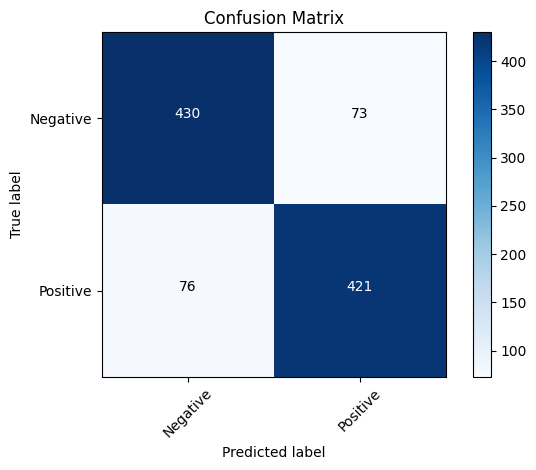

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize the text data
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train the Logistic Regression model
model.fit(X_train_vec, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_vec)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = [0, 1]
plt.xticks(tick_marks, ['Negative', 'Positive'], rotation=45)
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel("Predicted label")
plt.ylabel("True label")

# Add text annotations
import numpy as np
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

In [13]:
TfidfVectorizer(max_features=5000, ngram_range=(1,2))

TfidfVectorizer(max_features=5000, ngram_range=(1, 2))